In [1]:
import torch

t_c = [0.5, 14.0, 15.0, 28.0, 11.0, 8.0, 3.0,-4.0, 6.0, 13.0, 21.0]
t_u = [35.7, 55.9, 58.2, 81.9, 56.3, 48.9, 33.9, 21.8, 48.4, 60.4, 68.4]
t_c = torch.tensor(t_c)
t_u = torch.tensor(t_u)

In [2]:
def model (t_u, w, b):
    return w *t_u + b 

In [3]:
def loss_fn (t_p, t_c):
    diff = t_p - t_c
    squared = (diff) **2
    return squared.mean()

In [4]:
w = torch.ones(())
b = torch.ones(())

t_p = model(t_u, w, b)
t_p

tensor([36.7000, 56.9000, 59.2000, 82.9000, 57.3000, 49.9000, 34.9000, 22.8000,
        49.4000, 61.4000, 69.4000])

In [5]:
loss = loss_fn (t_p, t_c)
loss

tensor(1847.4844)

In [6]:
x = torch.ones(())
y = torch.ones(3,1)
z = torch.ones(1,3)
a = torch.ones(2,1,1)

In [7]:
print(f"shapes: x: {x.shape}, y: {y.shape}")
print(f" z: {z.shape}, a: {a.shape}")
print("x *y:", (x * y).shape)
print("y *z:", (y * z).shape)
print("y *z * a:", (y * z * a).shape)

shapes: x: torch.Size([]), y: torch.Size([3, 1])
 z: torch.Size([1, 3]), a: torch.Size([2, 1, 1])
x *y: torch.Size([3, 1])
y *z: torch.Size([3, 3])
y *z * a: torch.Size([2, 3, 3])


In [8]:
delta = 0.1
lr = 1e-2

loss_change_w = (loss_fn(model(t_u ,w+delta, b ), t_c) - loss_fn(model(t_u, w-delta, b), t_c)) / (2.0 * delta )
w = w - lr * loss_change_w
loss_change_b = (loss_fn(model(t_u, w, b+delta),t_c) - loss_fn(model(t_u, w, b-delta), t_c)) / (2.0 * delta)
b = b - lr * loss_change_b

In [9]:
def dloss_fn (t_p , t_c):
    sq = 2 * (t_p - t_c) / t_p.size(0)
    return sq


In [10]:
def dmodelw (t_u , w, b):
    return t_u

In [11]:
def dmodelb(t_u, w, b):
    return 1.0

In [12]:
def gradfn(t_u, t_c, t_p, w, b):
    dloss_tp = dloss_fn(t_p, t_c)
    dloss_dw = dloss_tp * dmodelw (t_u, w, b)
    dloss_db = dloss_tp *dmodelb(t_u, w, b)
    return torch.stack([dloss_dw.sum(), dloss_db.sum()])

In [13]:
params = torch.tensor([1.0 , 0.0], requires_grad= True)

In [ ]:
def training_loop (n_epochs, params, optimizer, t_u, t_c):
    for epoch in range (1, n_epochs+1):
        w, b = params

        t_p = model(t_u, *params)
        loss = loss_fn (t_p , t_c)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()


        print ('epoch %d, loss %f' %(epoch , float(loss)))

    return params

In [29]:
import torch.optim as optim
optimizer = optim.SGD([params], lr = 1e-2)
params = torch.tensor([1.0, 0.0], requires_grad= True)
learning_rate = 1e-2

training_loop(
    n_epochs = 5,
    params = params, 
    optimizer = optimizer,
    t_u = 0.1 * t_u ,
    t_c = t_c
)


epoch 1, loss 80.364342
epoch 2, loss 80.364342
epoch 3, loss 80.364342
epoch 4, loss 80.364342
epoch 5, loss 80.364342


tensor([1., 0.], requires_grad=True)

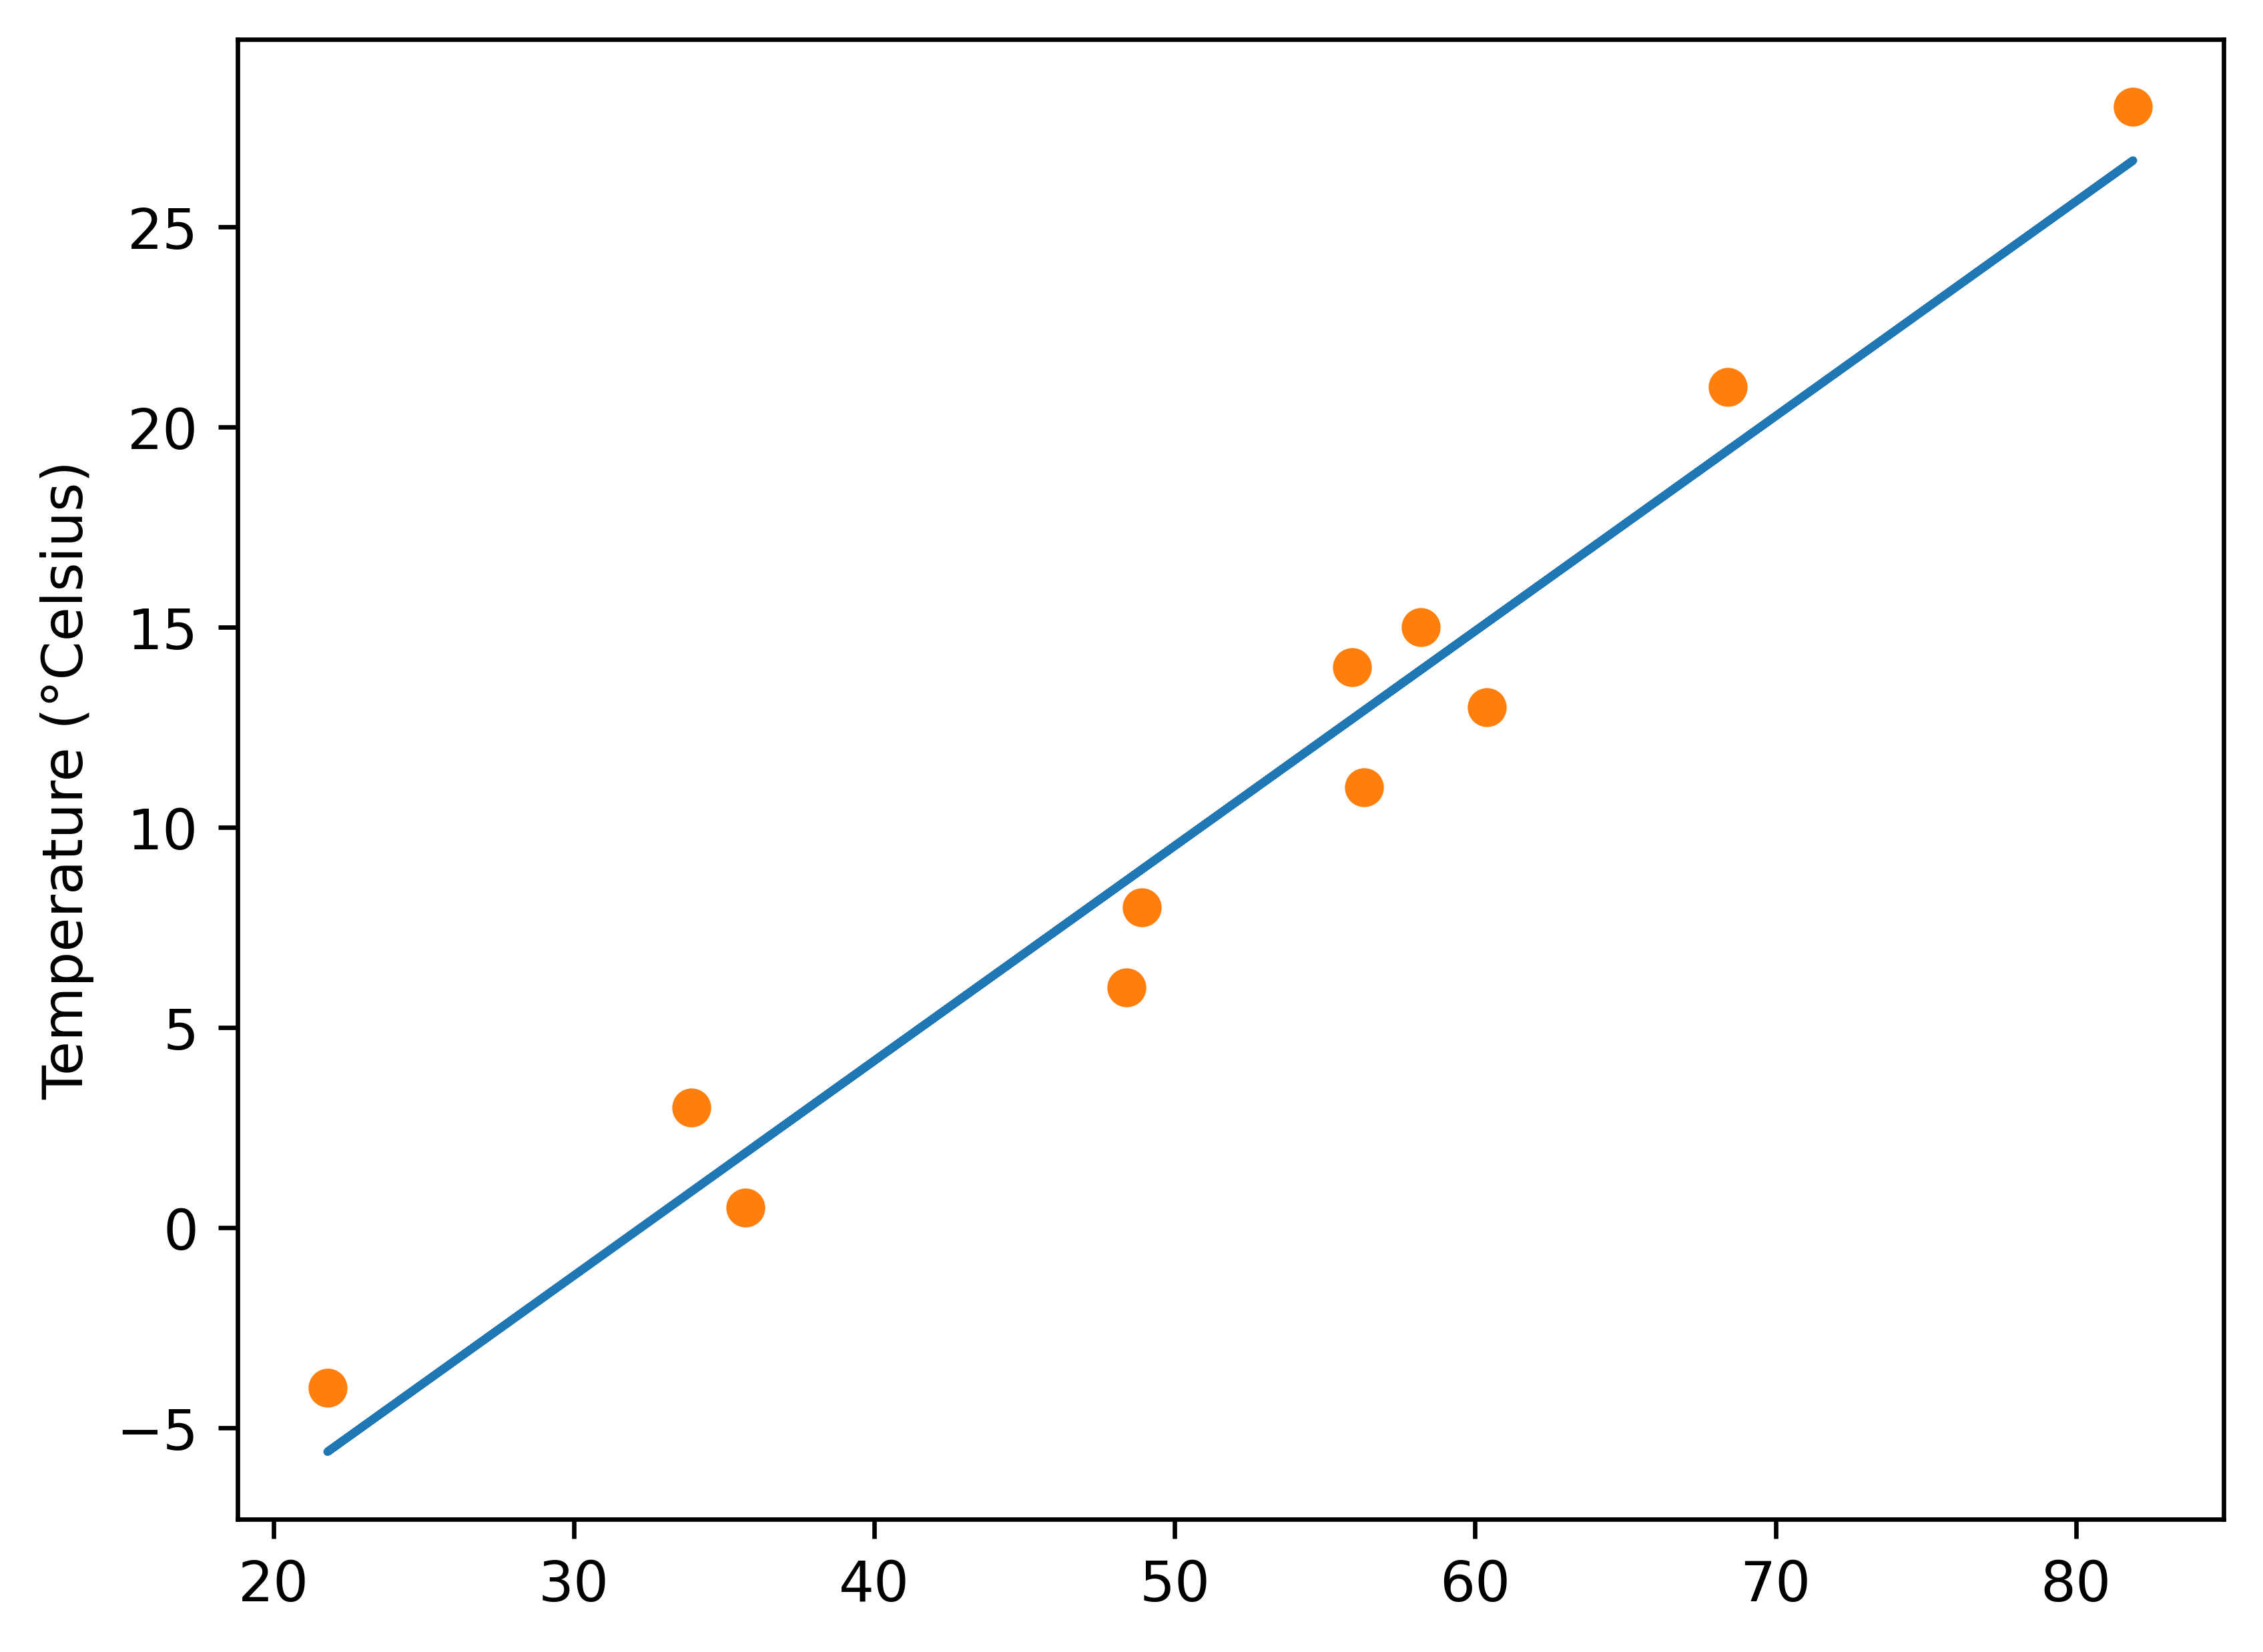

In [ ]:
from matplotlib import pyplot as plt 

t_p = model (t_u * 0.1 , *params)
figure = plt.figure(dpi = 600)
plt.ylabel("Temperature (°Celsius)")
plt.plot(t_u.numpy(), t_p.detach().numpy())
plt.plot(t_u.numpy(), t_c.numpy(), 'o')

In [31]:
n_samples = t_u.shape[0]
n_val = int(n_samples * 0.2)

shuffled_indices = torch.randperm(n_samples)
train_indices = shuffled_indices[:-n_val]
val_indices = shuffled_indices[-n_val:]

train_indices, val_indices

(tensor([ 4,  1, 10,  2,  9,  6,  8,  5,  3]), tensor([7, 0]))

In [32]:
train_tu = t_u[train_indices]
train_tc = t_c[train_indices]

val_tu = t_u[val_indices]
val_tc = t_c[val_indices]

train_t_un = 0.1 * train_tu
val_t_un = 0.1 * val_tu

In [38]:
def training_loop (n_epochs, params, optimizer, train_tu, train_tc, val_tu, val_tc):
    for epoch in range (1, n_epochs+1):
        w, b = params

        train_t_p = model(train_tu, *params)
        train_loss = loss_fn (train_t_p , train_tc)

        val_t_p = model(val_tu, *params)
        val_loss = loss_fn (val_t_p , val_tc)

        optimizer.zero_grad()
        train_loss.backward()
        optimizer.step()


        print ('epoch %d, loss %f' %(epoch , float(loss)))

    return params

In [39]:
params = torch.tensor([1.0, 0.0], requires_grad=True)
learning_rate = 1e-2
optimizer = optim.SGD([params], lr=learning_rate)
training_loop(
    n_epochs = 3,
    optimizer = optimizer,
    params = params,
    train_tu = train_t_un,
    val_tu = val_t_un,   
    train_tc = train_tc,
    val_tc = val_tc
)

epoch 1, loss 1847.484375
epoch 2, loss 1847.484375
epoch 3, loss 1847.484375


tensor([2.4001, 0.1822], requires_grad=True)